In [159]:
from stat import FILE_ATTRIBUTE_SPARSE_FILE
import pandas as pd
import numpy as np
import os 
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get current directory (works in Notebooks)
current_dir = os.getcwd()

# 2. Path: Go UP one level (../)
file_path = os.path.join(current_dir, "../data/final/master_accidents.csv")
# FILE_PATH = "../data/final/Master_Accident_Dataset.csv"

df = pd.read_csv(file_path)
print(df.shape)
print(df.columns)


(4473, 19)
Index(['accident_id', 'source', 'year', 'month', 'day_of_week', 'state',
       'vehicle_1', 'vehicle_2', 'vehicles_involved', 'party_age_group',
       'victim_age_group', 'cause_of_accident', 'weather_condition',
       'road_condition', 'lighting_condition', 'fatalities', 'injuries',
       'casualties', 'severity'],
      dtype='str')


In [144]:
print(df.dtypes)
df.head()
df.columns

accident_id             str
source                  str
year                  int64
month                   str
day_of_week             str
state                   str
vehicle_1               str
vehicle_2               str
vehicles_involved       str
party_age_group         str
victim_age_group        str
cause_of_accident       str
weather_condition       str
road_condition          str
lighting_condition      str
fatalities            int64
injuries              int64
casualties            int64
severity                str
dtype: object


Index(['accident_id', 'source', 'year', 'month', 'day_of_week', 'state',
       'vehicle_1', 'vehicle_2', 'vehicles_involved', 'party_age_group',
       'victim_age_group', 'cause_of_accident', 'weather_condition',
       'road_condition', 'lighting_condition', 'fatalities', 'injuries',
       'casualties', 'severity'],
      dtype='str')

# Understanding the distribution

In [145]:
df.describe()

,year,fatalities,injuries,casualties
count,4473.000000,4473.000000,4473.000000,4473.000000
mean,789.345853,1.049408,1.186899,3.124301
std,986.589570,2.549513,3.801826,4.940588
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,2022.000000,1.000000,0.000000,3.000000
max,2026.000000,79.000000,69.000000,79.000000


##### Step-1 State columns standardization

33


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\1270226235.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='viridis')


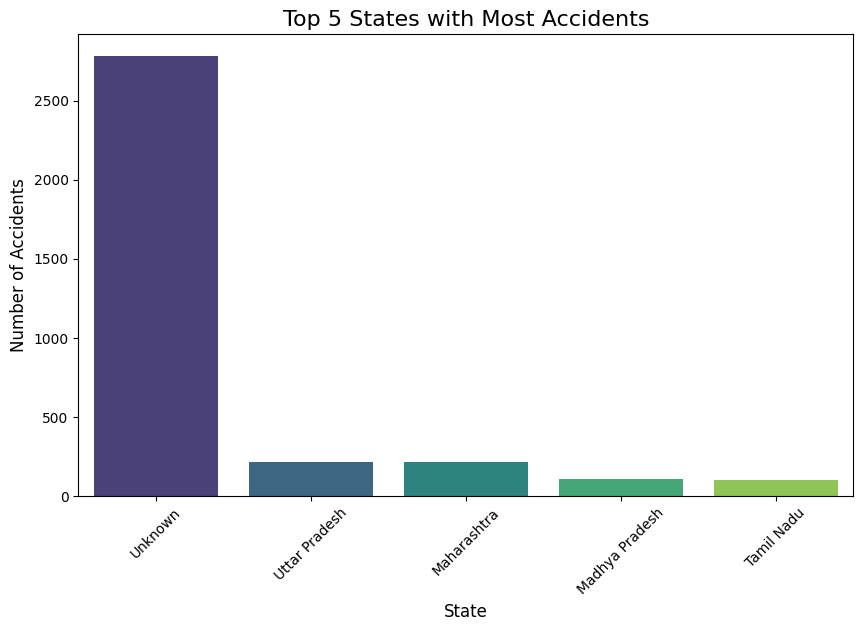

In [180]:
df['state'].value_counts()
# 1. Define the Correction Dictionary
state_corrections = {
    # Fix Typos
    'Maharastra': 'Maharashtra',
    'Rajesthan': 'Rajasthan',
    'Arnataka': 'Karnataka',
    
    # Fix Abbreviations & Regions
    'J & K': 'Jammu and Kashmir',
    'Jammu': 'Jammu and Kashmir',  # Map city/region to UT
    'Jammu And Kashmir': 'Jammu and Kashmir', # Standardize capitalization if needed
    
    # Note: Delhi, Chandigarh, and Puducherry are Union Territories 
    # and are correctly treated as state-level entities in Indian datasets.
}

# 2. Apply the corrections
df['state'] = df['state'].replace(state_corrections)

# 3. Verify the final clean list
print(df['state'].value_counts().count())

# 4. Get the top 5 states by count
top_5_states = df['state'].value_counts().nlargest(5)

# Visualize the Clean Data
plt.figure(figsize=(10,6))
sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='viridis')
plt.title('Top 5 States with Most Accidents', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45) # Rotate labels for readability
plt.show()


### OBSERVATION: State information was missing in a subset of the Kaggle and scraped datasets. To maintain data integrity and avoid introducing bias, these records were retained as 'Unknown' rather than being imputed.

#### Imputing and Handling missing columns

#### Dropping column not required for further analysis

In [106]:
df['year'].value_counts()

year
0       2727
2022     690
2023     590
2021      90
2025      83
2024      76
2020      74
2019      71
2018      62
2026      10
Name: count, dtype: int64

### Observation: The year column in the Kaggle dataset appears to be synthetically generated for the sole purpose of machine learning training, as it lacks realistic chronological details.

#### Month column visualization - Logical imputation


In [206]:
import pandas as pd
import random

# 1. Define the Smart Mapping using String Names
weather_to_month_names = {
    'Rainy': ['June', 'July', 'August', 'September'],
    'Fog/Mist': ['December', 'January'],
    'Cold': ['November', 'February'],
    'Clear': ['March', 'April', 'May', 'October']
}

# 2. Define the Imputation Function for Strings
def impute_month_string(row):
    # Check if month is missing
    if pd.isna(row['month']) or str(row['month']).lower() == 'nan':
        weather = str(row['weather_group']).strip()
        
        # Get matching months or default to all months if weather is unknown
        possible_months = weather_to_month_names.get(weather)
        
        if possible_months:
            return random.choice(possible_months)
        else:
            # Fallback: Pick any month from the full year
            all_months = [
                'January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December'
            ]
            return random.choice(all_months)
            
    # If month is already present, return it as is
    return row['month']

# 3. Apply to your main DataFrame
df['month'] = df.apply(impute_month_string, axis=1)

print("Smart Imputation (Strings) Complete!")
print(f"Remaining NaNs in month: {df['month'].isna().sum()}")

Smart Imputation (Strings) Complete!
Remaining NaNs in month: 0


Month        | Count
--------------------
January      | 163
February     | 140
March        | 758
April        | 742
May          | 773
June         | 225
July         | 207
August       | 254
September    | 232
October      | 711
November     | 124
December     | 144


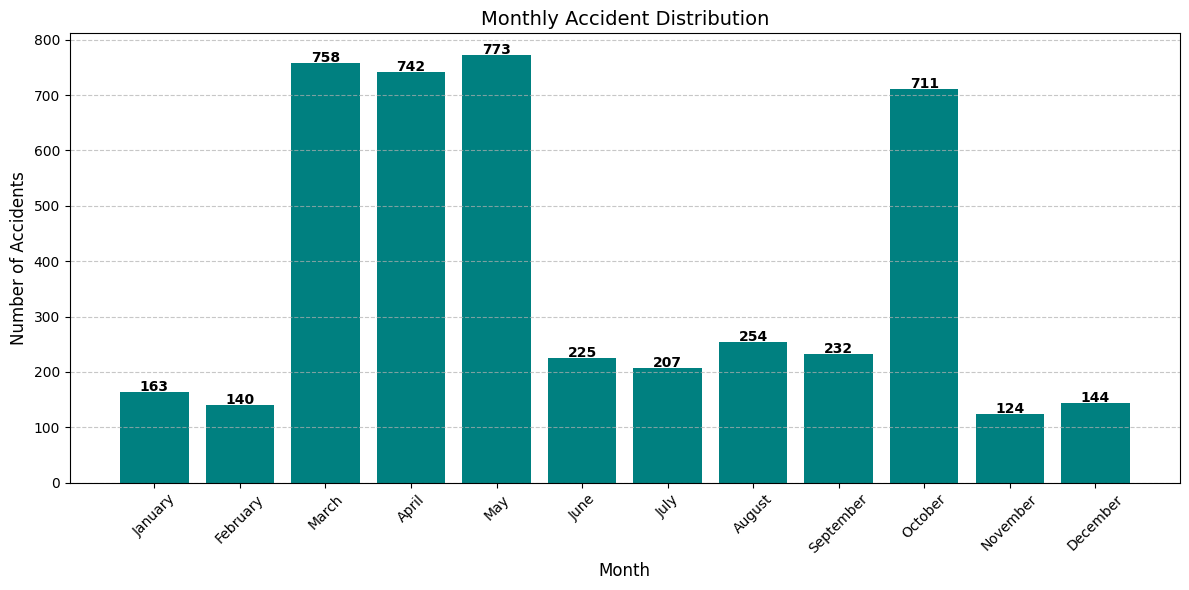

In [207]:
# 1. Get counts
month_counts = df['month'].value_counts()

# 2. Define the correct chronological order
correct_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# --- FIX: Reorder the data to match the calendar BEFORE plotting ---
month_counts_sorted = month_counts.reindex(correct_order, fill_value=0)

# 3. Print in Order
print(f"{'Month':<12} | {'Count'}")
print("-" * 20)
for month, count in month_counts_sorted.items():
    print(f"{month:<12} | {count}")

# 4. Visualize (Now using the sorted data)
plt.figure(figsize=(12, 6))

# Use the sorted index (Months) and values (Counts)
bars = plt.bar(month_counts_sorted.index, month_counts_sorted.values, color='teal')

plt.title('Monthly Accident Distribution', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the Count on Top
for bar in bars:
    yval = bar.get_height()
    # Only label bars that have data (height > 0)
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Visualizing Fatalities and Injuries using Boxplot 

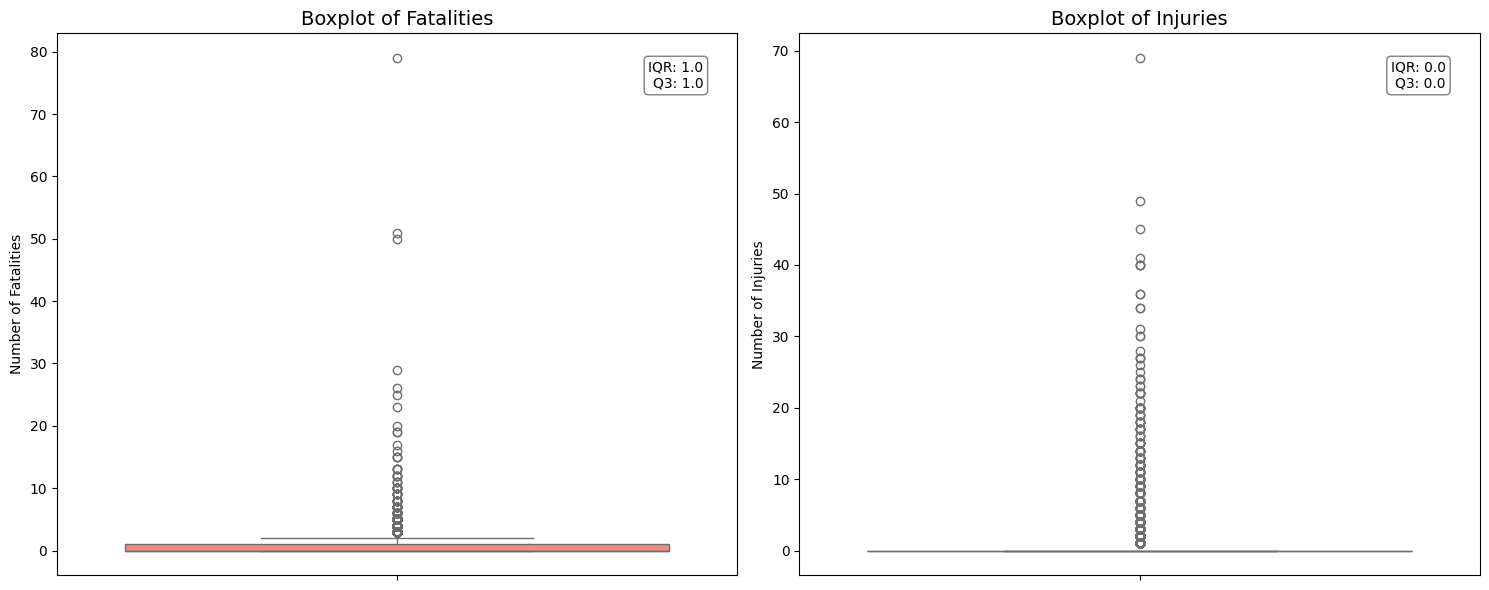


Outlier Thresholds (Anything above this is an outlier):
Fatalities > 2.5
Injuries   > 0.0


In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a figure with 2 subplots (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Plot Fatalities Boxplot
sns.boxplot(y=df['fatalities'], ax=axes[0], color='salmon')
axes[0].set_title('Boxplot of Fatalities', fontsize=14)
axes[0].set_ylabel('Number of Fatalities')

# Add the IQR text to the plot
Q1_fat = df['fatalities'].quantile(0.25)
Q3_fat = df['fatalities'].quantile(0.75)
IQR_fat = Q3_fat - Q1_fat
axes[0].text(0.95, 0.95, f'IQR: {IQR_fat}\nQ3: {Q3_fat}', 
             transform=axes[0].transAxes, ha='right', va='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 3. Plot Injuries Boxplot
sns.boxplot(y=df['injuries'], ax=axes[1], color='skyblue')
axes[1].set_title('Boxplot of Injuries', fontsize=14)
axes[1].set_ylabel('Number of Injuries')

# Add the IQR text to the plot
Q1_inj = df['injuries'].quantile(0.25)
Q3_inj = df['injuries'].quantile(0.75)
IQR_inj = Q3_inj - Q1_inj
axes[1].text(0.95, 0.95, f'IQR: {IQR_inj}\nQ3: {Q3_inj}', 
             transform=axes[1].transAxes, ha='right', va='top', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()
upper_bound_fat = Q3_fat + (1.5 * IQR_fat)
upper_bound_inj = Q3_inj + (1.5 * IQR_inj)

print(f"\nOutlier Thresholds (Anything above this is an outlier):")
print(f"Fatalities > {upper_bound_fat}")
print(f"Injuries   > {upper_bound_inj}")
# these data could not be removed based on outlier as there are accidents where casualities are more than 10 hence data retained for sevearity prediction


#### Vehicle_1 column standardization

vehicle_1
Truck             3342
Two Wheeler        403
Car                251
Bus                130
Pedestrian         130
Tractor             58
Suv                 45
Auto Rickshaw       37
Van                 29
Pick Up             12
Lorry               12
Bicycle              9
Ambulance            3
Tanker               3
Container            2
Jugaad Vehicle       1
Train                1
Tipper               1
Mini Truck           1
Volvo                1
Trailer              1
Crane                1
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\359214378.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vehicle_1', data=df, palette='viridis')


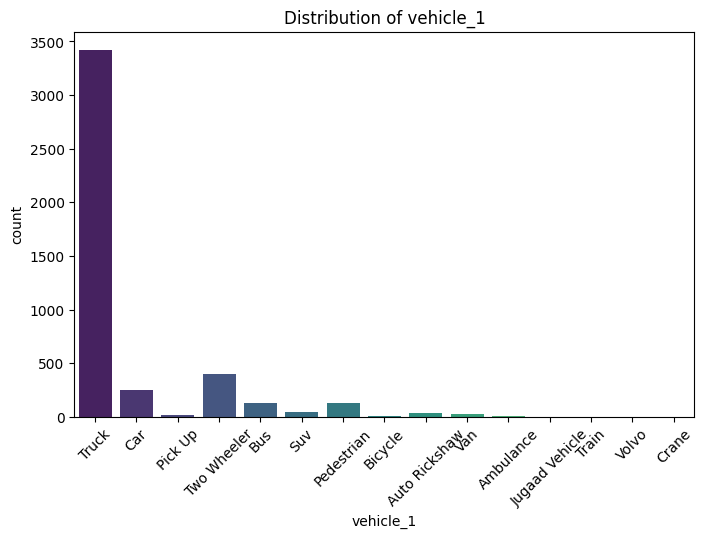

In [171]:
# analyzing vehicle_1 
print(df['vehicle_1'].value_counts())

# List of vehicles to group
heavy_vehicles = ['Tractor', 'Lorry', 'Tanker', 'Container', 'Tipper', 'Trailer', 'Mini Truck', 'crane','volvo']

df['vehicle_1'] = df['vehicle_1'].replace(heavy_vehicles,'Truck')

# Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='vehicle_1', data=df, palette='viridis')
plt.title('Distribution of vehicle_1')
plt.xticks(rotation = 45)
plt.show()

#### Vehicle_2 column standardization

vehicle_2
Unidentified     3303
Truck            1070
Car                42
Gorge              15
Two_Wheeler        14
Bus                11
Auto                5
Van                 3
Canal               2
Ditch               2
Wall                1
River               1
Ambulance           1
Divider             1
Auto Rickshaw       1
Bicycle             1
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\1997102034.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vehicle_2', data=df, palette='viridis')


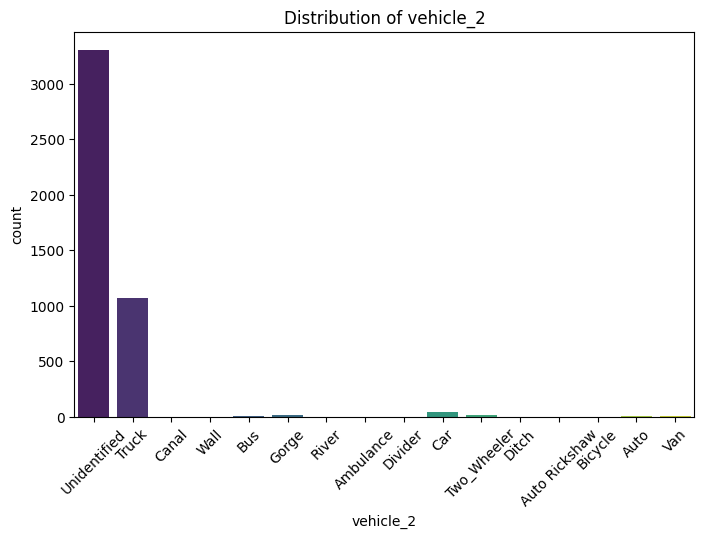

In [ ]:
# analyzing vehicle_1 
print(df['vehicle_2'].value_counts())

# List of vehicles to group
heavy_vehicles = ['Tractor', 'Lorry', 'Tanker', 'Container', 'Tipper', 'Trailer', 'Mini Truck','Canter','crane','volvo']

df['vehicle_2'] = df['vehicle_2'].replace(heavy_vehicles,'Truck')
df['vehicle_2'] = df['vehicle_2'].replace(['Unknown','Nil','Others'],'Unidentified')
cars = ['Suv','Pick Up','Fortuner','Bolero','Jeep','Innova']
df['vehicle_2'] = df['vehicle_2'].replace(cars,'Car')
df['vehicle_2'] = df['vehicle_2'].replace(['Bike','Scooter','Two Wheeler','Motorcycle'],'Two_Wheeler')

# Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='vehicle_2', data=df, palette='viridis')
plt.title('Distribution of vehicle_2')
plt.xticks(rotation = 45)
plt.show()

#### Vehicle_involved column standardization & imputing 

vehicles_involved
2          1944
Unknown    1297
1           535
3           441
4           155
5            92
6             9
Name: count, dtype: int64
vehicles_involved
2    3241
1     535
3     441
4     155
5      92
6       9
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\1054276102.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vehicles_involved', data=df, palette='viridis')


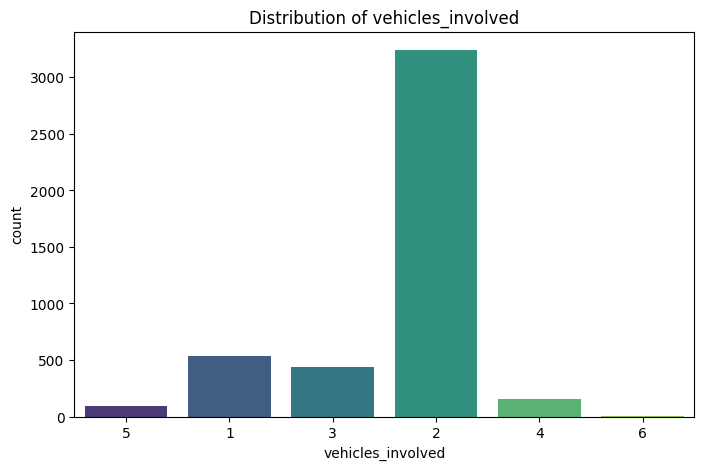

In [167]:
print(df['vehicles_involved'].value_counts())

# Imputing the unknown with mode value as this is not going to be used only in visulaization
mode_value = df['vehicles_involved'].mode()[0]
df['vehicles_involved'] = df['vehicles_involved'].replace('Unknown', mode_value)
print(df['vehicles_involved'].value_counts())

# Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='vehicles_involved', data=df, palette='viridis')
plt.title('Distribution of vehicles_involved')
plt.show()


#### Party_age_group and Victim age group standardization

In [165]:
print(df['party_age_group'].value_counts())
print(df['victim_age_group'].value_counts())
df['victim_age_group'] = df['victim_age_group'].replace(['19-30'],'18-30')
df['victim_age_group'] = df['victim_age_group'].replace(['31-45'],'31-50')
df['victim_age_group'] = df['victim_age_group'].replace(['0-18'],'Under 18')

party_age_group
Unknown     1633
31-50       1107
18-30       1065
Over 51      488
Under 18     180
Name: count, dtype: int64
victim_age_group
Unknown     2318
18-30        803
31-50        716
Under 18     357
Over 51      279
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\3161006449.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age Group', y='Count', data=df_party, order=age_order, ax=axes[0], palette='viridis')
C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\3161006449.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age Group', y='Count', data=df_victim, order=age_order, ax=axes[1], palette='magma')


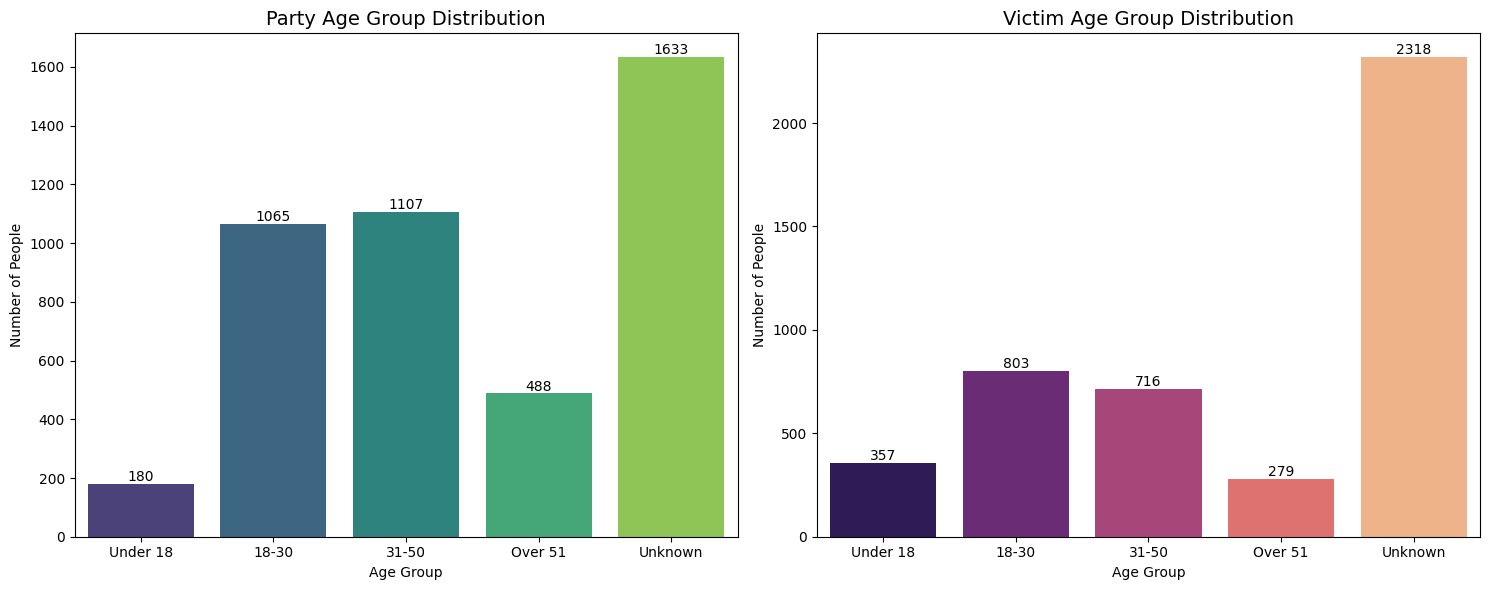

In [181]:
# 1. Visualize the Clean Data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Create the Data (Based on your input)
party_data = {
    'Unknown': 1633,
    '31-50': 1107,
    '18-30': 1065,
    'Over 51': 488,
    'Under 18': 180
}

victim_data_raw = {
    'Unknown': 2318,
    '18-30': 802,
    '31-50': 715,
    'Under 18': 350,
    'Over 51': 279,
    '0-18': 7,    # Needs cleaning
    '31-45': 1,   # Needs cleaning
    '19-30': 1    # Needs cleaning
}

# 2. Clean Victim Age Group Logic
# We merge the small messy groups into the big standard ones
victim_data_clean = {
    'Unknown': 2318,
    '18-30': 802 + 1,      # Added '19-30' (1)
    '31-50': 715 + 1,      # Added '31-45' (1)
    'Under 18': 350 + 7,   # Added '0-18' (7)
    'Over 51': 279
}

# Convert to DataFrame for easier plotting
df_party = pd.DataFrame(list(party_data.items()), columns=['Age Group', 'Count'])
df_victim = pd.DataFrame(list(victim_data_clean.items()), columns=['Age Group', 'Count'])

# Define a standard order for the x-axis
age_order = ['Under 18', '18-30', '31-50', 'Over 51', 'Unknown']

# 3. Create the Subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Party Age Group
sns.barplot(x='Age Group', y='Count', data=df_party, order=age_order, ax=axes[0], palette='viridis')
axes[0].set_title('Party Age Group Distribution', fontsize=14)
axes[0].set_ylabel('Number of People')

# Add labels on top of bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plot 2: Victim Age Group
sns.barplot(x='Age Group', y='Count', data=df_victim, order=age_order, ax=axes[1], palette='magma')
axes[1].set_title('Victim Age Group Distribution', fontsize=14)
axes[1].set_ylabel('Number of People')

# Add labels on top of bars
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


#### Normalizing cause of accident columns to make it suitable for ML model 

cause_of_accident
No Distancing/Rear End    997
Reckless Driving          905
Lane Violation            880
Unknown/Other             816
Severe Collision          405
Loss of Control           151
Parking Issue             137
Speeding                   96
Drunk/Drug Driving         86
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\1200876614.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= 'cause_of_accident', data=df, palette='viridis', order=['No Distancing/Rear End','Reckless Driving','Lane Violation','Unknown/Other','Severe Collision','Loss of Control',


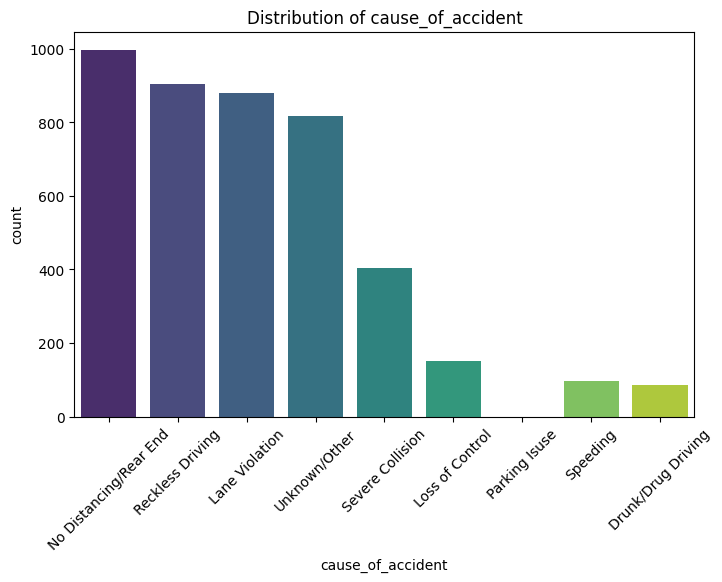

In [163]:
df['cause_of_accident'].value_counts()

# 1. Define the Semantic Mapping Dictionary
cause_mapping = {
    # Lane Violations
    'Changing Lane To The Right': 'Lane Violation',
    'Changing Lane To The Left': 'Lane Violation',
    'Driving To The Left': 'Lane Violation',
    'Overtaking': 'Lane Violation',

    # Distancing & Rear-End (Often related)
    'No Distancing': 'No Distancing/Rear End',
    'Hit From Back': 'No Distancing/Rear End',
    'Moving Backward': 'No Distancing/Rear End',

    # Reckless & Rules
    'Driving Carelessly': 'Reckless Driving',
    'No Priority To Vehicle': 'Reckless Driving',
    'No Priority To Pedestrian': 'Reckless Driving',
    'Hit And Run': 'Reckless Driving',
    'Getting Off The Vehicle Improperly': 'Reckless Driving',
    
    # Severe Collisions
    'Head On Collision': 'Severe Collision',
    'Hit From Side': 'Severe Collision',
    'Collision': 'Severe Collision',
    'Fixed Object Collision': 'Severe Collision',

    # Speeding
    'Overspeeding': 'Speeding',
    'Driving At High Speed': 'Speeding',
    'Overspeed': 'Speeding',

    # Loss of Control
    'Overturning': 'Loss of Control',
    'Run Off Road': 'Loss of Control',
    'Vehicle Overturn': 'Loss of Control',
    'Turnover': 'Loss of Control',
    'Overloading': 'Loss of Control',

    # Parking
    'With Parked Vehicle': 'Parking Issue',
    'Improper Parking': 'Parking Issue',

    # DUI
    'Driving Under The Influence Of Drugs': 'Drunk/Drug Driving',
    'Drunk Driving': 'Drunk/Drug Driving',

    # Generalize Unknowns
    'Others': 'Unknown/Other',
    'Other': 'Unknown/Other',
    'Unknown': 'Unknown/Other'
}

# 2. Apply the Mapping
df['cause_of_accident'] = df['cause_of_accident'].replace(cause_mapping)

# 3. Handle the "Noise" (News Headlines & Rare Events)
# Any cause that appears less than 5 times is likely a scraping error/headline
counts = df['cause_of_accident'].value_counts()
rare_labels = counts[counts < 5].index.tolist()

# Replace those rare labels with 'Unknown/Other'
df['cause_of_accident'] = df['cause_of_accident'].replace(rare_labels, 'Unknown/Other')

# 4. Verify the Final 10 Categories
print(df['cause_of_accident'].value_counts())

# 5. Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x= 'cause_of_accident', data=df, palette='viridis', order=['No Distancing/Rear End','Reckless Driving','Lane Violation','Unknown/Other','Severe Collision','Loss of Control',
                                                                         'Parking Isuse','Speeding','Drunk/Drug Driving'])
plt.title('Distribution of cause_of_accident')
plt.xticks(rotation =45)
plt.show()

#### Standardizing weather_condition column

In [155]:
df['weather_condition'].value_counts()

weather_condition
Normal               2215
Unknown              1350
Raining               325
Rainy                 104
Hazy                   97
Stormy                 88
Foggy                  88
Clear                  72
Other                  60
Cloudy                 31
Windy                  22
Snow                   12
Raining And Windy       6
Fog Or Mist             3
Name: count, dtype: int64

 Weather Successfully Grouped into 4 Classes:
weather_group
Clear       3750
Rainy        523
Fog/Mist     188
Cold          12
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\2891223947.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather_group', data=df, palette='viridis', order=['Clear', 'Rainy', 'Fog/Mist', 'Cold'])


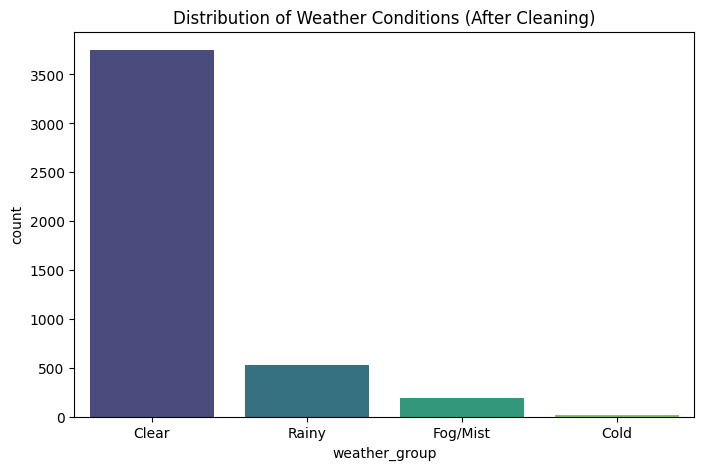

In [201]:
# 1. Handle Missing/Unknown Values First (Impute with Mode)
mode_weather = 'Normal'
df['weather_condition'] = df['weather_condition'].replace(['Unknown', 'Other', 'None'], mode_weather)

# 2. Define the Mapping Logic (14 types -> 4 Classes)
def group_weather(w):
    w = str(w).lower().strip()
    
    # Class 1: Rainy (The Wet Group)
    if w in ['raining', 'rainy', 'stormy', 'raining and windy']:
        return 'Rainy'
    
    # Class 2: Fog/Mist (The Visibility Group)
    elif w in ['foggy', 'hazy', 'fog or mist']:
        return 'Fog/Mist'
    
    # Class 3: Cold (The Winter Group)
    elif w in ['snow', 'cold', 'winter']:
        return 'Cold'
    
    # Class 4: Clear (The Default/Good Group)
    # Includes Normal, Clear, Cloudy, Windy
    else:
        return 'Clear'

# 3. Apply the Grouping
df['weather_group'] = df['weather_condition'].apply(group_weather)

# 4. Verify the New Counts
print(" Weather Successfully Grouped into 4 Classes:")
print(df['weather_group'].value_counts())

# 5. Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='weather_group', data=df, palette='viridis', order=['Clear', 'Rainy', 'Fog/Mist', 'Cold'])
plt.title('Distribution of Weather Conditions (After Cleaning)')
plt.show()

In [203]:
df.drop('weather_condition',axis =1, inplace =True)

Scattering Logic: Dry (72.15%) vs Wet (27.85%)
road_condition
Dry                     3065
Wet                     1183
Damaged/Construction     225
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\3035854456.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='road_condition', data=df, palette='viridis', order=['Dry','Wet','Damaged/Construction'])


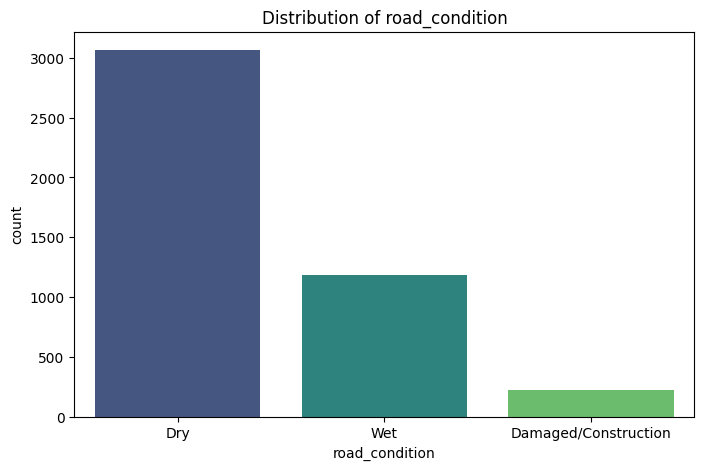

In [200]:

# 1. Standardize Categories (Merging Duplicates first)
road_mapping = {
    'Wet Or Damp': 'Wet',
    'Wet': 'Wet',
    'Under Construction': 'Damaged/Construction',
    'Damaged': 'Damaged/Construction',
    'Snow': 'Wet' # Snow is rare in india
}
df['road_condition'] = df['road_condition'].replace(road_mapping)

# 2. Identify the Top 2 Categories for Scattering
top_1 = 'Dry'
top_2 = 'Wet'

# Calculate their counts in the KNOWN data
count_1 = df[df['road_condition'] == top_1].shape[0]
count_2 = df[df['road_condition'] == top_2].shape[0]
total_known = count_1 + count_2

# Calculate Probabilities (Weights)
prob_1 = count_1 / total_known
prob_2 = count_2 / total_known

print(f"Scattering Logic: {top_1} ({prob_1:.2%}) vs {top_2} ({prob_2:.2%})")

# 3. Apply Scattering to 'Unknown' values
# Find the rows that are 'Unknown'
mask = df['road_condition'] == 'Unknown'
missing_count = mask.sum()

# Generate random choices based on the calculated probabilities
imputed_values = np.random.choice([top_1, top_2], size=missing_count, p=[prob_1, prob_2])

# Fill them in
df.loc[mask, 'road_condition'] = imputed_values

# 4. Verify the Result
print(df['road_condition'].value_counts())

# 5. Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='road_condition', data=df, palette='viridis', order=['Dry','Wet','Damaged/Construction'])
plt.title('Distribution of road_condition')
plt.show()


Scattering Logic: Daylight (69.52%) vs Dark (30.48%)
lighting_condition
Daylight    2949
Dark        1293
Twilight     231
Name: count, dtype: int64


C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\2337069428.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='lighting_condition', data=df, palette='viridis', order =['Daylight','Dark','Twilight'])


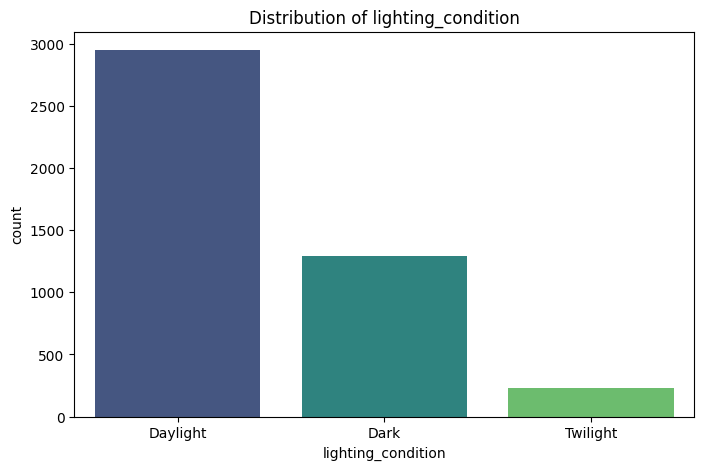

In [193]:
df['lighting_condition'].value_counts()

import numpy as np

# 1. Standardize Categories (Group all "Darkness" variants together)
lighting_mapping = {
    # Merge all Dark variants into one 'Dark' bucket
    'Darkness - Lights Lit': 'Dark',
    'Darkness - No Lighting': 'Dark',
    'Darkness - Lights Unlit': 'Dark',
    
    # Merge Dawn/Dusk into 'Twilight' (Distinct from Day/Dark)
    'Dusk': 'Twilight',
    'Dawn': 'Twilight'
}
df['lighting_condition'] = df['lighting_condition'].replace(lighting_mapping)

# 2. Identify the Top 2 Categories for Scattering
# Daylight (~2043) vs Dark (~900) are the top 2
top_1 = 'Daylight'
top_2 = 'Dark'

# Calculate their counts in the KNOWN data
count_1 = df[df['lighting_condition'] == top_1].shape[0]
count_2 = df[df['lighting_condition'] == top_2].shape[0]
total_known = count_1 + count_2

# Calculate Probabilities
prob_1 = count_1 / total_known
prob_2 = count_2 / total_known

print(f"Scattering Logic: {top_1} ({prob_1:.2%}) vs {top_2} ({prob_2:.2%})")

# 3. Apply Scattering to 'Unknown' values
mask = df['lighting_condition'] == 'Unknown'
missing_count = mask.sum()

# Generate random choices
imputed_values = np.random.choice([top_1, top_2], size=missing_count, p=[prob_1, prob_2])

# Fill them in
df.loc[mask, 'lighting_condition'] = imputed_values

# 4. Verify the Result
print(df['lighting_condition'].value_counts())


# 5. Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='lighting_condition', data=df, palette='viridis', order =['Daylight','Dark','Twilight'])
plt.title('Distribution of lighting_condition')
plt.show()

C:\Users\SMANIVE\AppData\Local\Temp\ipykernel_12100\3528256917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='severity', data=df, palette='viridis', order =['Minor','Fatal','Serious'])


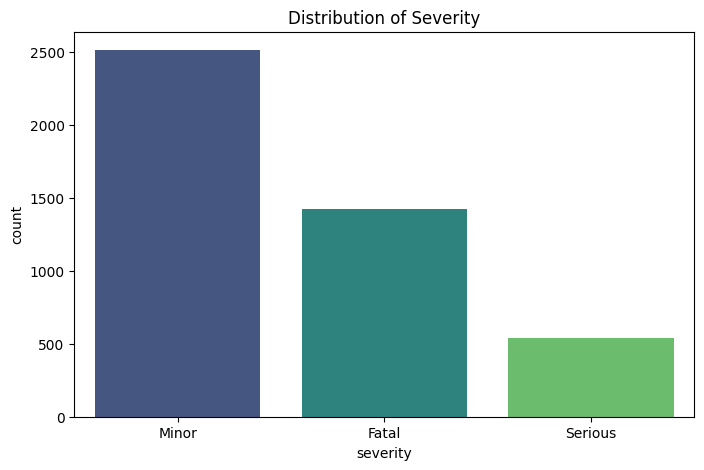

In [194]:
df['severity'].value_counts()

# Visualize the Clean Data
plt.figure(figsize=(8, 5))
sns.countplot(x='severity', data=df, palette='viridis', order =['Minor','Fatal','Serious'])
plt.title('Distribution of Severity')
plt.show()

In [210]:
print(df['fatalities'].value_counts())
print(df['injuries'].value_counts())

fatalities
0     2860
1      597
2      322
3      241
4      181
5      140
6       52
7       22
8       13
10      10
9        8
12       5
13       4
11       3
15       3
19       2
16       1
79       1
50       1
51       1
17       1
26       1
29       1
20       1
25       1
23       1
Name: count, dtype: int64
injuries
0     3507
1      265
2      138
3       96
4       82
5       68
7       52
6       51
8       40
10      31
9       22
12      16
20      15
11      13
14      10
15       8
13       8
17       7
18       6
22       5
19       4
16       3
24       3
40       3
27       3
34       2
23       2
36       2
30       2
31       1
26       1
69       1
41       1
28       1
45       1
25       1
49       1
21       1
Name: count, dtype: int64


In [209]:
df.to_csv("../data/final/accident_ml_data.csv")

In [211]:
df.columns

Index(['accident_id', 'source', 'year', 'month', 'day_of_week', 'state',
       'vehicle_1', 'vehicle_2', 'vehicles_involved', 'party_age_group',
       'victim_age_group', 'cause_of_accident', 'road_condition',
       'lighting_condition', 'fatalities', 'injuries', 'casualties',
       'severity', 'weather_group'],
      dtype='str')